In [1]:
# Potato_Disease_Prediction Using Generator Method

In [3]:
# Import all packages
import tensorflow as tf
import keras
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


from keras.preprocessing.image import load_img, img_to_array
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras import Sequential
from keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
# Path to the dataset
path = Path(
    r'C:\7M\Artificial Intelligence\Potato_Disease_Prediction\PlantVillage'
)
print(path)

C:\7M\Artificial Intelligence\Potato_Disease_Prediction\PlantVillage


In [4]:
# by using ImageDatagenerator

# steps create object of image data generator

# rescale
# validation split
# data aug >> parameter >> shear flip

In [5]:
train_gen = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [6]:
test_gen = ImageDataGenerator(rescale=1/255,
                              validation_split=0.2,
                              )

In [7]:
train_data = train_gen.flow_from_directory(
    path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

Found 2084 images belonging to 3 classes.


In [8]:
test_data = test_gen.flow_from_directory(
    path,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

Found 519 images belonging to 3 classes.


In [9]:
class_dict = train_data.class_indices

In [10]:
class_dict

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [11]:
labels = list(train_data.class_indices.keys())

In [12]:
labels

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [13]:
for i, j in train_data:
    print(i[0], j[0])
    break

[[[0.6610074  0.5982623  0.637478  ]
  [0.65106285 0.58831775 0.62753344]
  [0.6707943  0.6080492  0.6472649 ]
  ...
  [0.60232824 0.5356616  0.5670341 ]
  [0.59663296 0.52996624 0.5613388 ]
  [0.5900232  0.52335656 0.5547291 ]]

 [[0.67905873 0.61631364 0.6555293 ]
  [0.64556897 0.5828239  0.62203956]
  [0.667655   0.6049099  0.6441256 ]
  ...
  [0.5459659  0.47929928 0.5106718 ]
  [0.53501254 0.46834588 0.49971843]
  [0.51721483 0.45054814 0.4819207 ]]

 [[0.69711    0.6343649  0.6735806 ]
  [0.64007515 0.57733    0.61654574]
  [0.6645156  0.6017705  0.6409862 ]
  ...
  [0.44002527 0.3733586  0.40473115]
  [0.46138254 0.39471588 0.42608842]
  [0.48273984 0.41607314 0.4474457 ]]

 ...

 [[0.7318826  0.6809022  0.72011787]
  [0.7325945  0.6816141  0.7208298 ]
  [0.7333064  0.682326   0.7215417 ]
  ...
  [0.7365269  0.6737818  0.7129975 ]
  [0.7642304  0.7014853  0.74070096]
  [0.7289455  0.6662004  0.7054161 ]]

 [[0.7114936  0.6605132  0.6997289 ]
  [0.7065103  0.65552986 0.6947456 ]


2
Potato___healthy


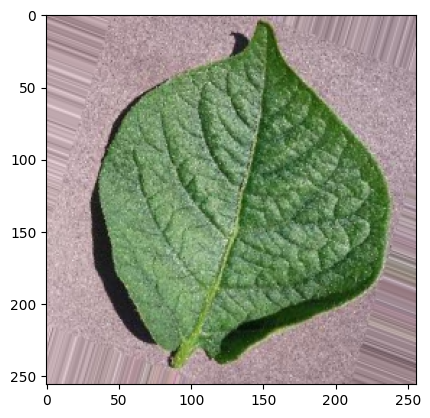

In [14]:
for i, j in train_data:
    plt.imshow(i[0])
    print(np.argmax(j[0]))
    print(labels[np.argmax(j[0])])
    break

In [15]:
a = train_data.classes
pd.Series(a).value_counts()

0    800
1    800
2    484
Name: count, dtype: int64

In [16]:
# Model Traning

In [17]:
model = keras.Sequential([
    keras.layers.Input(shape=(256, 256, 3)),

    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(256, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

In [18]:
model.compile(optimizer='adam',
               loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_data, epochs=10, validation_data=(test_data))

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.4290 - loss: 1.0369 - val_accuracy: 0.5800 - val_loss: 0.9546
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.4918 - loss: 0.9468 - val_accuracy: 0.5877 - val_loss: 0.9007
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 64s 958ms/step - accuracy: 0.6895 - loss: 0.6615 - val_accuracy: 0.9017 - val_loss: 0.2941
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 59s 884ms/step - accuracy: 0.8119 - loss: 0.4652 - val_accuracy: 0.8998 - val_loss: 0.3383
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 763ms/step - accuracy: 0.8992 - loss: 0.2572 - val_accuracy: 0.9191 - val_loss: 0.2017
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 56s 852ms/step - accuracy: 0.9218 - loss: 0.2124 - val_accuracy: 0.9133 - val_loss: 0.3285
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9410 - loss: 0.1786 - val_accuracy: 0.9114 - val_loss: 0.1950
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9487 - loss: 0.1529 - val_accuracy: 0.9518

In [38]:
# Traing data accuracy >> 95.30%

In [39]:
model.evaluate(train_data)

66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 316ms/step - accuracy: 0.9453 - loss: 0.1320


[0.13203343749046326, 0.9452974796295166]

In [40]:
# Testing data accuracy >> 94.52%

In [41]:
y_pred = model.predict(test_data)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step


In [42]:
y_pred1 = [np.argmax(i) for i in y_pred]

In [43]:
act_op=test_data.classes

In [44]:
print(classification_report(act_op, y_pred1))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       199
           1       0.98      0.98      0.98       200
           2       0.97      0.97      0.97       120

    accuracy                           0.98       519
   macro avg       0.98      0.98      0.98       519
weighted avg       0.98      0.98      0.98       519



In [45]:
print(confusion_matrix(act_op, y_pred1))

[[198   1   0]
 [  0 196   4]
 [  0   4 116]]


In [46]:
print(accuracy_score(act_op, y_pred1))

0.9826589595375722


In [47]:
model.save('Potato_Disease_Prediction.keras')

In [131]:
model = load_model('Potato_Disease_Prediction.keras')

In [132]:
img1 = load_img(
    r'C:\7M\Artificial Intelligence\img0.jpg', target_size=(256, 256))

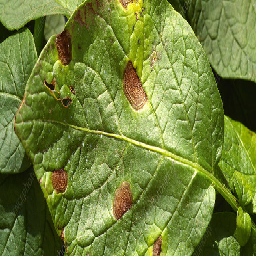

In [113]:
img1

In [114]:
img1 = img_to_array(img1)

In [115]:
img1.shape

(256, 256, 3)

In [116]:
img2 = img1/255.0

In [117]:
img3 = np.reshape(img2,shape=(1,256,256,3))

In [118]:
labels[np.argmax(model.predict(img3))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


'Potato___Early_blight'

In [119]:
class_dict

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [141]:
img2 = load_img(r'C:\7M\Artificial Intelligence\img1.jpg',target_size=(256,256))

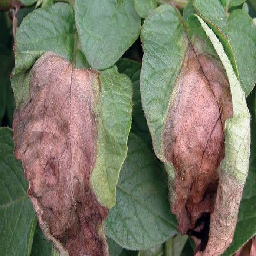

In [142]:
img2

In [143]:
img2=img_to_array(img2)

In [144]:
img2.shape

(256, 256, 3)

In [145]:
img2=img2/255.0

In [146]:
img2.shape

(256, 256, 3)

In [147]:
img3 = np.reshape(img2, shape=(1,256,256,3))

In [148]:
labels[np.argmax(model.predict(img3))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


'Potato___Late_blight'

In [150]:
labels

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [152]:
img3 = load_img(r'C:\7M\Artificial Intelligence\img2.jpg', target_size=(256,256))

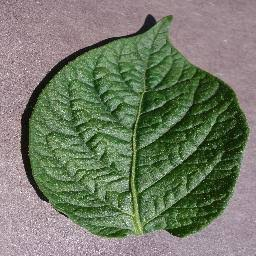

In [153]:
img3

In [154]:
img2=img_to_array(img3)

In [155]:
img2.shape

(256, 256, 3)

In [156]:
img2=img2/255.0

In [157]:
img3 = np.reshape(img2, shape=(1,256,256,3))

In [158]:
img3.shape

(1, 256, 256, 3)

In [159]:
labels[np.argmax(model.predict(img3))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


'Potato___healthy'